<a href="https://colab.research.google.com/github/ewondare/Anomaly_Detection_With_GP/blob/main/GP_Anomaly_Detection_Arrythmia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ANOMALY DETECTION USING GENETIC PROGRAMING**


<figure>
<table border = 5 align = center>
<tr>
<td width=50%>
    <img src="https://towardsdatascience.com/wp-content/uploads/2021/07/1da44wm6KVB1PGsv8UEGnLA.png" />
</td>
<td width=50%>
    <img src="https://geneticprogramming.com/wp-content/uploads/2016/05/Genetic_Program_Tree.png" />
</td>
</tr>
</table>
</figure>

# 0. Introduction
## *Anomaly Detection*
Anomaly detection, sometimes called outlier detection, is a process of finding patterns or instances in a dataset that deviate significantly from the expected or “normal behavior.”

The definition of both “normal” and anomalous data significantly varies depending on the context. Below are a few examples of anomaly detection in action.

## *Genetic Programming* (In DEAP)

To see a given function, one can simply print out an individual candidate solution to see the string representation. However, it is possible to generate a figure.

Genetic programming is a special field of evolutionary computation that aims at building programs automatically to solve problems independently of their domain. Although there exist diverse representations used to evolve programs, the most common is the syntax tree.



<figure>
<table border = 5 align = center>
<tr>
<td width=100%>
    <img src="https://deap.readthedocs.io/en/master/_images/gptree.png" />
</td>
</tr>
</table>
</figure>

For example, the above figure presents the program $\max(x + 3 * y, x + x)$. For this tree and further examples, the leaves of the tree, in green, are called terminals, while the internal nodes, in red, are called primitives. The terminals are divided in two subtypes: the constants and the arguments. The constants remain the same for the entire evolution while the arguments are the program inputs. For the last presented tree, the arguments are the variables $x$ and $y$, and the constant is the number $3$.

In DEAP, user defined primitives and terminals are contained in a primitive set. For now, two kinds of primitive set exists: the loosely and the strongly typed.


In [3]:
!pip install deap

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from deap import base, creator, tools, gp
import operator
import random
import warnings
warnings.filterwarnings("ignore")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 4.1 MB/s eta 0:00:00


# 1.Dataset Introduction: UCI Arrhythmia Dataset
**What is this dataset about?**

The Arrhythmia dataset, hosted by the UCI Machine Learning Repository, is a medical dataset used to classify cardiac arrhythmias. It contains ECG (electrocardiogram) features extracted from patients' heart signals. The goal is to detect whether a patient's ECG pattern is normal or indicative of a specific arrhythmia (a form of irregular heartbeat).

Identifying arrhythmias early is critical because certain types can lead to serious health complications, including stroke or cardiac arrest.



In [4]:
# Load Arrhythmia dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/arrhythmia/arrhythmia.data"
df = pd.read_csv(url, header=None, na_values='?')

**Dataset structure:**

The dataset consists of 452 samples, each with 279 attributes. These attributes are mostly numeric and correspond to various signal measurements extracted from ECG recordings. At the end of each row is the target column, which contains an integer value ranging from 1 to 16. This value represents the type of arrhythmia diagnosed for that patient. Class '1' corresponds to a normal heartbeat, while classes '2' through '16' represent different categories of arrhythmic events.

The target column is highly imbalanced, with a majority of instances falling under Class 1 (normal rhythm), and far fewer examples representing each arrhythmic condition. This imbalance makes the dataset particularly suitable for anomaly detection. By framing the problem as a binary classification task—labeling Class 1 as "normal" and all others as "anomalous"—we can leverage anomaly detection algorithms to identify rare and potentially dangerous heart conditions. This approach simulates a realistic clinical scenario, where the primary challenge is to detect a small number of abnormal cases hidden within a large population of healthy individuals.

In [5]:
df

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,53,1,160,70,80,199,382,154,117,-37,...,0.0,4.3,-5.0,0.0,0.0,0.7,0.6,-4.4,-0.5,1
448,37,0,190,85,100,137,361,201,73,86,...,0.0,15.6,-1.6,0.0,0.0,0.4,2.4,38.0,62.4,10
449,36,0,166,68,108,176,365,194,116,-85,...,0.0,16.3,-28.6,0.0,0.0,1.5,1.0,-44.2,-33.2,2
450,32,1,155,55,93,106,386,218,63,54,...,-0.4,12.0,-0.7,0.0,0.0,0.5,2.4,25.0,46.6,1


# 2. Preproccessing

In [6]:
df.fillna(df.mean(), inplace=True) # NaN enties replacedd with the mean of the column

In [7]:
# Split features and target:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


# Since this is an Anomaly DEtection, we will see any type of anomalous result as 1 and normals as 0
# Binary label: 0 = normal, 1 = anomaly
y_binary = y.apply(lambda x: 0 if x == 1 else 1)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.3, random_state=42)

One Chromosome will look like this:
(we model each row to be one point in our population.)

In [9]:
X.head(1)

,0,1,2,3,4,5,6,7,8,9,...,269,270,271,272,273,274,275,276,277,278
0,75,0,190,80,91,193,371,174,121,-16,...,-0.3,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4


**Simplifying things before beginning the program**:

We have a dataset where normal cases are common (label 0) and anomalies are rare (label 1). we want to evolve a mathematical expression that can take in feature values and separate anomalies from normal cases. (Takes the Shape of a Tree)

So you're not using a neural network or random forest — you're evolving a formula like:

`(x1 * x3 - x2) > threshold → anomaly or not ` (E1)


# 3. Using GP and DEAP library to create the model:

In [10]:
# Define primitive set for GP / we set the “grammar” of our evolved programs to be able to make expressions like E1:
pset = gp.PrimitiveSet("MAIN", X_train.shape[1])

#We also define Funcitons and Terminals to use in the Tree
pset.addPrimitive(operator.add, 2) #gets two inputs
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(operator.neg, 1)
pset.addEphemeralConstant("rand101", lambda: random.uniform(-1, 1))
pset.renameArguments(**{f"ARG{i}": f"x{i}" for i in range(X_train.shape[1])})


Fitness Function in DEAP: A built-in object that holds the result of your evaluation (e.g., accuracy), and is used by DEAP to compare individuals. Uses Output of Evalluation Function to internally guide the evolution.

In [11]:
# Fitness function
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", gp.PrimitiveTree, fitness=creator.FitnessMax)

The `toolbox` registers the functions that define your evolutionary process.

In [12]:
# we also create individuals (solutions) and populations
toolbox = base.Toolbox()
toolbox.register("expr", gp.genHalfAndHalf, pset=pset, min_=1, max_=3)
toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.expr)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("compile", gp.compile, pset=pset)


In [33]:
!pip install graphviz

In [14]:
# Evaluation function
# When GP creates expressions like E1, for each row we evaluate the expression
# Then we threshold the output to classify it as normal/anomaly
# Thrn we compare these predicted tagrets from fitness function with the actual targets
def evalAnomaly(individual):
    func = toolbox.compile(expr=individual)
    pred = np.array([func(*x) for x in X_train])
    pred_labels = (pred > np.median(pred)).astype(int)
    return (np.mean(pred_labels == y_train),)

Within DEAP there are two ways of using operators. We can either simply call a function from the tools module or register it with its arguments in a toolbox, as we have already seen for our initialization methods. The most convenient way, however, is to register them in the toolbox, because this allows us to easily switch between the operators if desired. The toolbox method is also used when working with the algorithms module.

In [15]:
toolbox.register("evaluate", evalAnomaly)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("mate", gp.cxOnePoint)
toolbox.register("mutate", gp.mutUniform, expr=toolbox.expr, pset=pset)

toolbox.decorate("mate", gp.staticLimit(key=len, max_value=17))
toolbox.decorate("mutate", gp.staticLimit(key=len, max_value=17))

In [26]:
#First we set ngen = 25:
from deap import algorithms
random.seed(42)
pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)
pop, log = algorithms.eaSimple(
    pop, toolbox,
    cxpb=0.6,     # crossover probability
    mutpb=0.3,    # mutation probability
    ngen=25,      # number of generations
    stats=stats,
    halloffame=hof,
    verbose=True
)

gen	nevals	avg     	max     
0  	100   	0.520728	0.620253
1  	71    	0.546329	0.623418
2  	70    	0.553133	0.639241
3  	71    	0.561139	0.702532
4  	73    	0.566013	0.651899
5  	63    	0.572373	0.651899
6  	72    	0.586361	0.658228
7  	67    	0.603418	0.658228
8  	71    	0.592057	0.686709
9  	80    	0.587911	0.664557
10 	71    	0.606614	0.686709
11 	78    	0.609241	0.686709
12 	71    	0.611582	0.686709
13 	79    	0.609177	0.689873
14 	70    	0.615158	0.705696
15 	72    	0.623323	0.727848
16 	86    	0.627658	0.737342
17 	76    	0.640127	0.727848
18 	74    	0.6525  	0.753165
19 	76    	0.667215	0.762658
20 	76    	0.675253	0.762658
21 	71    	0.683766	0.762658
22 	76    	0.685538	0.753165
23 	69    	0.705158	0.762658
24 	81    	0.701361	0.765823
25 	71    	0.698038	0.765823


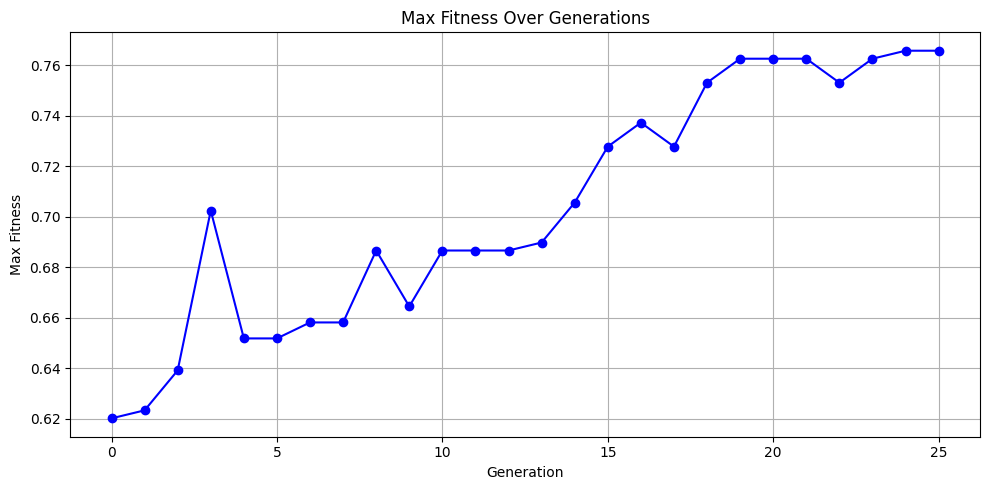

In [27]:
import matplotlib.pyplot as plt

max_fitness = log.select("max")

plt.figure(figsize=(10, 5))
plt.plot(range(len(max_fitness)), max_fitness, marker='o', linestyle='-', color='blue')
plt.title("Max Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Max Fitness")
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
from deap import algorithms

random.seed(42)
pop = toolbox.population(n=100)
hof = tools.HallOfFame(1)

stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("max", np.max)
pop, log = algorithms.eaSimple(
    pop, toolbox,
    cxpb=0.6,     # crossover probability
    mutpb=0.3,    # mutation probability
    ngen=35,      # number of generations (now 35)
    stats=stats,
    halloffame=hof,
    verbose=True
)


gen	nevals	avg     	max     
0  	100   	0.520728	0.620253
1  	71    	0.546329	0.623418
2  	70    	0.553133	0.639241
3  	71    	0.561139	0.702532
4  	73    	0.566013	0.651899
5  	63    	0.572373	0.651899
6  	72    	0.586361	0.658228
7  	67    	0.603418	0.658228
8  	71    	0.592057	0.686709
9  	80    	0.587911	0.664557
10 	71    	0.606614	0.686709
11 	78    	0.609241	0.686709
12 	71    	0.611582	0.686709
13 	79    	0.609177	0.689873
14 	70    	0.615158	0.705696
15 	72    	0.623323	0.727848
16 	86    	0.627658	0.737342
17 	76    	0.640127	0.727848
18 	74    	0.6525  	0.753165
19 	76    	0.667215	0.762658
20 	76    	0.675253	0.762658
21 	71    	0.683766	0.762658
22 	76    	0.685538	0.753165
23 	69    	0.705158	0.762658
24 	81    	0.701361	0.765823
25 	71    	0.698038	0.765823
26 	70    	0.705222	0.759494
27 	81    	0.710506	0.765823
28 	73    	0.724019	0.768987
29 	78    	0.725222	0.772152
30 	76    	0.729114	0.772152
31 	76    	0.733323	0.772152
32 	75    	0.732595	0.772152
33 	73    	0.7

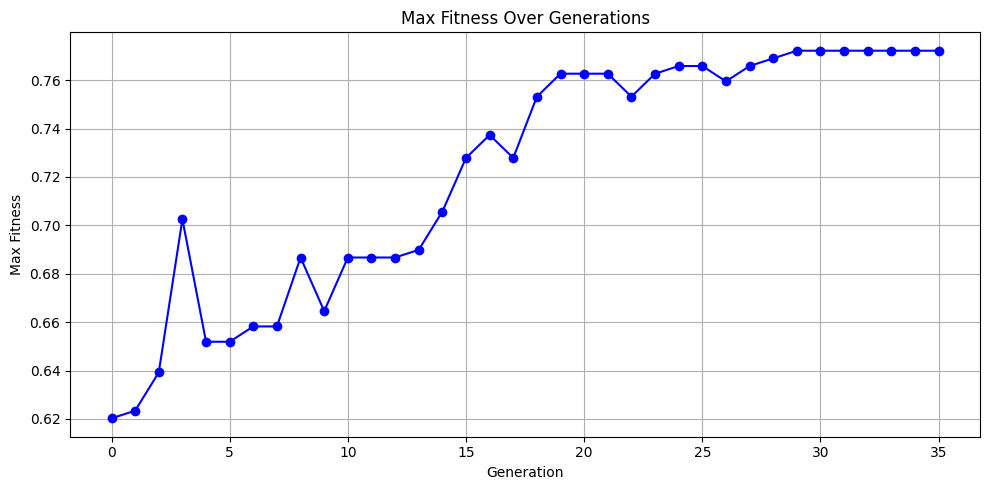

In [36]:
import matplotlib.pyplot as plt

max_fitness = log.select("max")

plt.figure(figsize=(10, 5))
plt.plot(range(len(max_fitness)), max_fitness, marker='o', linestyle='-', color='blue')
plt.title("Max Fitness Over Generations")
plt.xlabel("Generation")
plt.ylabel("Max Fitness")
plt.grid(True)
plt.tight_layout()
plt.show()


It seems like the algorithm has converged by 35 generations.

In [37]:
# Get the best function
best_func = toolbox.compile(expr=hof[0])
pred_test = np.array([best_func(*x) for x in X_test])
pred_test_labels = (pred_test > np.median(pred_test)).astype(int)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, pred_test_labels, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.6912    0.6812    0.6861        69
           1     0.6765    0.6866    0.6815        67

    accuracy                         0.6838       136
   macro avg     0.6838    0.6839    0.6838       136
weighted avg     0.6839    0.6838    0.6838       136



# Acknowledgments
- Genetic Algorithms with DEAP:
  - https://colab.research.google.com/github/jfogarty/machine-learning-intro-workshop/blob/master/notebooks/genetic-algorithms-with-deap.ipynb#scrollTo=SNWdHmYGcHxs
  - https://deap.readthedocs.io/en/master/tutorials/advanced/gp.html

- UCI Arrhythmia Dataset:
  - https://archive.ics.uci.edu/dataset/5/arrhythmia

- Anomaly Detection:
  -  https://www.datacamp.com/tutorial/introduction-to-anomaly-detection